In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def explicit_euler(func, y_o, dt, t, a):
    res = np.zeros(len(t), dtype="float")

    for n, _ in enumerate(t):
        y = y_o + func(n * dt, y_o, a) * dt
        res[n] = y
        y_o = y
    return res

In [14]:
def runge_kutta_4(func, y_o, dt, t, a):
    res = np.zeros(len(t), dtype="float")

    for n, _ in enumerate(t):
        k_1 = func(n*dt, y_o, a)
        k_2 = func(n*dt + dt/2, y_o + dt/2 * k_1, a)
        k_3 = func(n*dt + dt/2, y_o + dt/2 * k_2, a)
        k_4 = func(n*dt + dt, y_o + dt * k_3, a)

        y = y_o + ((k_1 + 2*k_2 + 2*k_3 + k_4)/6.) * dt
        res[n] = y
        y_o = y
    return res


In [15]:
numerical_method_registry = {
    'explicit_euler': explicit_euler,
    'runge_kutta_4': runge_kutta_4,
                    }

In [16]:
def func_one(t, y, a):
    return -a * y

def analytic_one(t, a):
    return np.exp(-a * t)


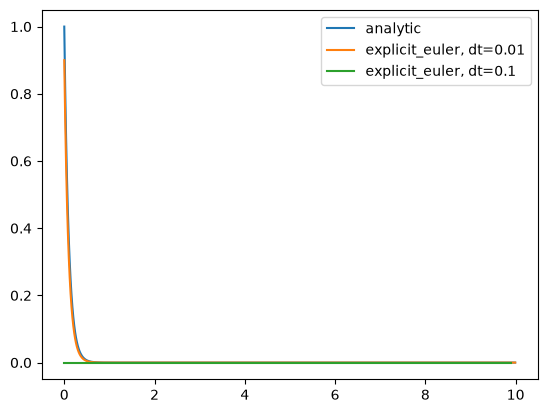

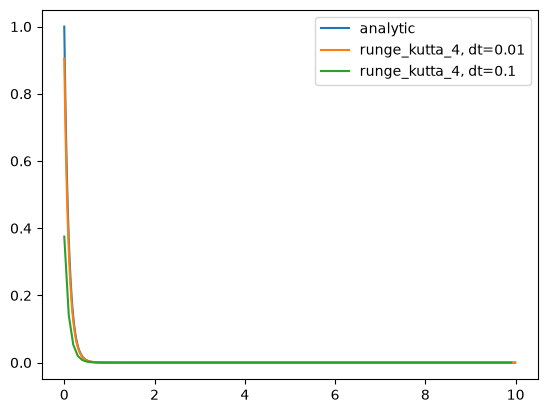

In [17]:
dt = 0.1
N = 10
y_o = 1
a = 10

def compare_results(res_analytic, func, y_o, a, dt_list, N, method='explicit_euler'):
    t = np.arange(0, N, dt_list[0])
    plt.plot(t, res_analytic(t, a), label="analytic")

    num_method = numerical_method_registry[method]

    for dt in dt_list:
        t = np.arange(0, N, dt)
        res = num_method(func, y_o, dt, t, a)
        plt.plot(t, res, label=f"{method}, dt={dt}")
    
    plt.legend(loc="upper right")
    plt.show()

dt_list = [0.01, 0.1]
compare_results(analytic_one, func_one, y_o, a, dt_list, N)
compare_results(analytic_one, func_one, y_o, a, dt_list, N, method='runge_kutta_4')


In [18]:
def func_two(t, y, a):
    return a * y - 2 * a

def analytic_two(t, a):
    return 2 - np.exp(a * t)

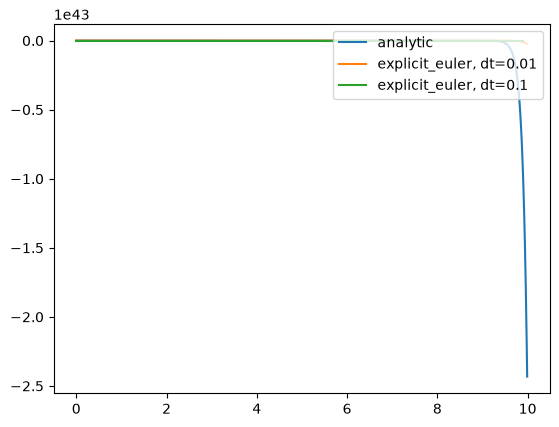

In [19]:
dt = 0.1
N = 10
y_o = 1
a = 10

dt_list = [0.01, 0.1]
compare_results(analytic_two, func_two, y_o, a, dt_list, N)

In [20]:
def func_three(t, y, a):
    return -a * y * y * np.sin(t)

def analytic_three(t, a):
    return a / (2 - a * np.cos(t))


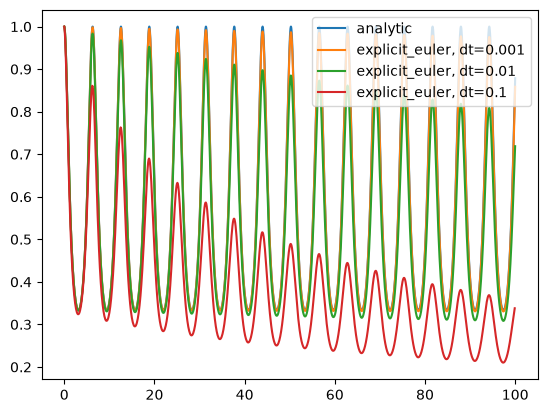

In [21]:

dt = 0.1
N = 100
y_o = 1
a = 1
dt_list = [0.001, 0.01, 0.1]
compare_results(analytic_three, func_three, y_o, a, dt_list, N, method='explicit_euler')

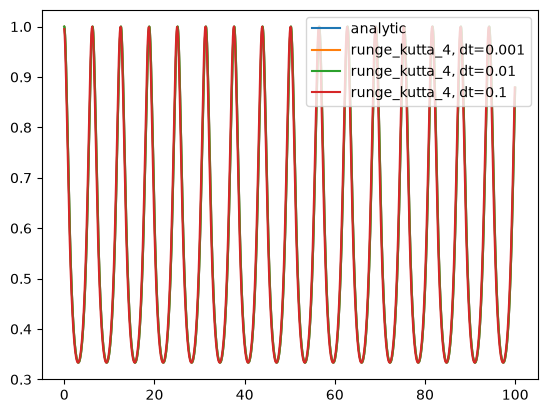

In [22]:
dt = 0.1
N = 100
y_o = 1
a = 1
dt_list = [0.001, 0.01, 0.1]
compare_results(analytic_three, func_three, y_o, a, dt_list, N, method='runge_kutta_4')